# 03 — Algoritmos Genéticos

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar soluciones mediante cromosomas;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- analizar el balance entre exploración y explotación.

![HillClimbing](https://drive.google.com/uc?export=view&id=1XSZ2ppaVR85ZRJErD0-0tB4aP26ReY5H)

## 1. Problema OneMax

Cada individuo es una cadena binaria de longitud $L$. Queremos maximizar el número de unos:

$$
\text{fitness}(x)=\sum_{i=1}^{L}x_i
$$

El óptimo global es una cadena formada completamente por unos. Es un problema sencillo, pero permite observar con claridad todos los componentes de un algoritmo genético.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 14
random.seed(SEED)
np.random.seed(SEED)


def create_individual(length, rng):
    return [rng.randint(0, 1) for _ in range(length)]


def fitness(individual):
    return sum(individual)


def as_string(individual):
    return ''.join(map(str, individual))

rng = random.Random(SEED)
example = create_individual(20, rng)
print(as_string(example), 'fitness =', fitness(example))

00111011111010111100 fitness = 13


## 2. Selección por torneo

Elegimos varios individuos al azar y seleccionamos el de mayor fitness. El tamaño del torneo controla la **presión de selección**.

In [2]:
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()

population = [create_individual(12, rng) for _ in range(8)]
selected = tournament_selection(population, tournament_size=3, rng=rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

Seleccionado: 110111111001 fitness = 9


## 3. Cruce de un punto

Dos padres intercambian fragmentos de sus cromosomas.

In [3]:
def one_point_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = one_point_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11110111
Hijo 2 : 00001000


## 4. Mutación

Cada bit cambia con probabilidad $p_m$. La mutación introduce diversidad y puede recuperar información genética que desapareció de la población.

In [4]:
def mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = 1 - child[i]
    return child

before = [0] * 20
after = mutate(before, mutation_rate=0.15, rng=rng)
print('Antes  :', as_string(before))
print('Después:', as_string(after))

Antes  : 00000000000000000000
Después: 00000000000010001011


## 5. Algoritmo genético completo

Incluiremos **elitismo**: el mejor individuo pasa directamente a la siguiente generación.

In [5]:
def genetic_algorithm(
    chromosome_length=40,
    population_size=60,
    generations=100,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0
):
    if mutation_rate is None:
        mutation_rate = 1 / chromosome_length

    rng = random.Random(seed)
    population = [create_individual(chromosome_length, rng)
                  for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness(ind) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        if fitness(best) == chromosome_length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size, rng)
            parent2 = tournament_selection(population, tournament_size, rng)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history

best, history = genetic_algorithm(seed=SEED)
print('Mejor individuo:', as_string(best))
print('Fitness:', fitness(best), '/', len(best))
print('Generaciones ejecutadas:', history[-1]['generation'])

Mejor individuo: 1111111111111111111111111111111111111111
Fitness: 40 / 40
Generaciones ejecutadas: 16


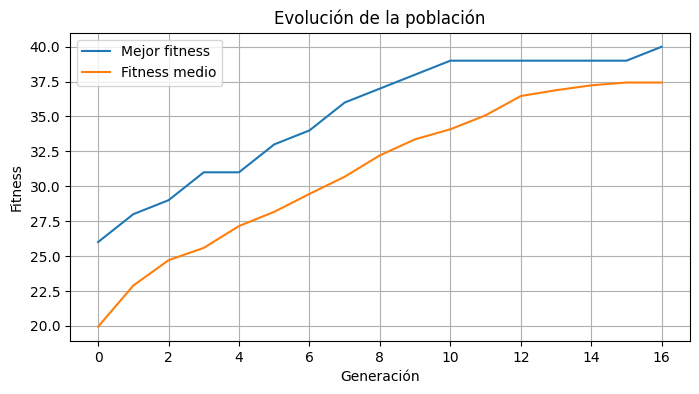

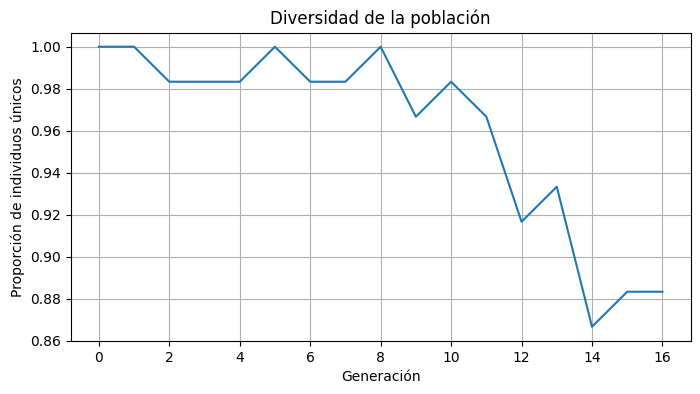

In [6]:
generations = [h['generation'] for h in history]
best_values = [h['best'] for h in history]
mean_values = [h['mean'] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(generations, best_values, label='Mejor fitness')
plt.plot(generations, mean_values, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(generations, [h['diversity'] for h in history])
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad de la población')
plt.grid(True)
plt.show()

## 6. Efecto de la mutación

Una tasa muy baja puede producir convergencia prematura. Una tasa muy alta destruye las estructuras que el cruce intenta conservar.

In [ ]:
rates = [0.0, 0.005, 0.025, 0.1, 0.5]
summary = []

for rate in rates:
    final_fitness = []
    generations_used = []
    for seed in range(20):
        best, hist = genetic_algorithm(
            chromosome_length=40,
            generations=120,
            mutation_rate=rate,
            seed=seed
        )
        final_fitness.append(fitness(best))
        generations_used.append(hist[-1]['generation'])
    summary.append((rate, np.mean(final_fitness), np.mean(generations_used)))

print('mutation_rate | fitness medio | generaciones medias')
for row in summary:
    print(f'{row[0]:>13.3f} | {row[1]:>13.2f} | {row[2]:>18.2f}')

## Actividades

### Actividad 1 — Selección por ruleta

Implementa selección proporcional al fitness. Ten cuidado con poblaciones donde todos los individuos tengan fitness cero.

In [ ]:
def roulette_selection(population, rng):
    fitnesses = [fitness(ind) for ind in population]
    total = sum(fitnesses)
    if total == 0:
        return population[rng.randrange(len(population))].copy()
    pick = rng.random() * total
    current = 0
    for ind, f in zip(population, fitnesses):
        current += f
        if current >= pick:
            return ind.copy()
    return population[-1].copy()


### Actividad 2 — Cruce uniforme

En cada posición, el hijo toma el gen del padre 1 o del padre 2 con igual probabilidad.

In [ ]:
def uniform_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() > crossover_rate:
        return parent1.copy(), parent2.copy()
    child1 = []
    child2 = []
    for a, b in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(a)
            child2.append(b)
        else:
            child1.append(b)
            child2.append(a)
    return child1, child2


### Actividad 3 — Frase objetivo

Adapta el algoritmo para evolucionar una cadena hasta alcanzar una frase objetivo, por ejemplo `INTELIGENCIA ARTIFICIAL`.

Sugerencias:

- cromosoma: lista de caracteres;
- fitness: número de caracteres correctos en la posición correcta;
- alfabeto: letras, espacio y, opcionalmente, signos de puntuación.

In [ ]:
# Actividad 3: evolucionar una frase objetivo
SEED_PHRASE = 123
rng_phrase = random.Random(SEED_PHRASE)
target = "INTELIGENCIA ARTIFICIAL"
alphabet = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ ")

def create_char_individual(length, rng):
    return [rng.choice(alphabet) for _ in range(length)]

def fitness_phrase(ind):
    return sum(1 for a, b in zip(ind, target) if a == b)

def mutate_phrase(ind, mutation_rate, rng):
    return [ (rng.choice(alphabet) if rng.random() < mutation_rate else g) for g in ind ]

def crossover_phrase(p1, p2, crossover_rate, rng):
    return uniform_crossover(p1, p2, crossover_rate, rng)

# Parámetros y ejecución simple
population_size = 200
mutation_rate = 0.05
crossover_rate = 0.7
generations = 1000

population = [create_char_individual(len(target), rng_phrase) for _ in range(population_size)]
for gen in range(generations):
    fitnesses = [fitness_phrase(ind) for ind in population]
    best_idx = int(np.argmax(fitnesses))
    best = population[best_idx]
    print(f"Gen {gen}: best={fitnesses[best_idx]} - {''.join(best)}")
    if fitnesses[best_idx] == len(target):
        print("Encontrado en generación", gen)
        break
    new_pop = []
    while len(new_pop) < population_size:
        p1 = roulette_selection(population, rng_phrase)
        p2 = roulette_selection(population, rng_phrase)
        c1, c2 = crossover_phrase(p1, p2, crossover_rate, rng_phrase)
        c1 = mutate_phrase(c1, mutation_rate, rng_phrase)
        c2 = mutate_phrase(c2, mutation_rate, rng_phrase)
        new_pop.extend([c1, c2])
    population = new_pop[:population_size]


### Actividad 4 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo. ¿Puede disminuir el mejor fitness de una generación a la siguiente? Explica el resultado.

In [ ]:
# Actividad 4: comparar con y sin elitismo y observar si el mejor puede disminuir
best_e, hist_e = genetic_algorithm(seed=SEED, elitism=True)
bests_e = [h['best'] for h in hist_e]
best_ne, hist_ne = genetic_algorithm(seed=SEED, elitism=False)
bests_ne = [h['best'] for h in hist_ne]
print("Con elitismo - mejores por generación:", bests_e)
print("Sin elitismo - mejores por generación:", bests_ne)
print("¿Disminución en sin elitismo?:", any(bests_ne[i] < bests_ne[i-1] for i in range(1, len(bests_ne))))


## Preguntas de cierre

1. ¿Qué papel cumple la población que no existe en Hill Climbing? — Respuesta: En Hill Climbing no hay población; se trabaja con un único candidato que se mejora iterativamente. En los algoritmos genéticos la población mantiene diversidad y permite explorar múltiples soluciones simultáneamente.
2. ¿Por qué el cruce no garantiza hijos mejores que sus padres? — Respuesta: El cruce mezcla material genético de los padres y puede romper combinaciones útiles; la recombinación no asegura que las combinaciones resultantes sean mejores. Además la selección y la mutación influyen en si aparecen soluciones superiores.
3. ¿Qué significa convergencia prematura? — Respuesta: Es cuando la población pierde diversidad y se estanca en un óptimo local antes de explorar el espacio de soluciones, impidiendo encontrar soluciones mejores.
4. ¿Qué parámetros controlan la exploración? — Respuesta: Tamaño de población, tasa de mutación, tasa de cruce, presión de selección (p.ej. tamaño de torneo), y si hay elitismo o mecanismos de diversificación.
